## HNN para Osciladores Acoplados com Desordem

### 1. Osciladores Acoplados com Desordem

#### 1.1 O Oscilador Harmônico Simples

O oscilador harmônico simples pode ser uma massa presa a uma mola ideal. Sendo $q$ p deslocamento da massa em relação ao equilíbrio, a mola exerce uma força F = -kq, com as leis de Newton:

$$m \ddot{q} = -kq$$

A resolução é um movimento senoidal:
$$
q(t) = Acos(\omega t + \phi)
$$

Sendo $\omega$ a frequência natural do oscilador. A massa oscilaria para sempre com mesma amplitude sem perder a energia, dada por:
$$
E = 1/2 m \ddot{p} + 1/2 k q^2
$$

No espaço (q, p), em que p é o momento linear, as trajetórias de OHS são elipses fechadas, consequência direta da conservação de energia.

#### 1.2 O Hamiltoniano

Primeiramente, entendamos o Hamiltoniano. Ele aparece com William Rowan Hamilton no século XIX que reformula a mecânica newtoniana. Ele expressa tudo em termos de uma única função escalar, o Hamiltoniano H(q, p). Em sistemas conservativos, o Hamiltoniano é simplesmente a energia total e podemos escrever as equações do movimento da seguinte forma:

$dq/dt = + \partial H/ \partial p$

$dp/dt = - \partial H/ \partial q$

#### 1.3 Espaço de Fases

Para um sistema com N graus de liberdade, o espaço de fases é um espaço 2N-dimensional com coordendas $(q_1, p_1,..., 1_n, p_n)$

Cada ponto no espaço de fases representa um estado completo do sistema. Cada trajetória no espaço de fases representa a evolução temporal do sistema.

#### 1.4 Osciladores Desacoplados

Imagine dois pêndulos no mesmo suporte rígido. Se o suporte é completamente imóvel, eles oscilam independentemente, cada um com sua própria frequência. O Hamiltoniano é simplesmente a soma:

$H = 1/2 p_1^2 + 1/2 k_1q_1^2 + 1/2p_2^2 + 1/2 k_2q_2^2$

A energia de cada oscilador é separadamente conservada.

#### 1.5 O acoplamento

Agora, se os dois pêndulos estiverem pendurados no mesmo cabo elástico, o movimento de um vai afetar o outro, sendo isso denominado acoplamento. O Hamiltoniano vai ganhar um termo de interação:

$H = 1/2 p_1^2 + 1/2 k_1q_1^2 + 1/2p_2^2 + 1/2 k_2q_2^2 + J_{12} q_1q_2$

O parâmetro $J_{12}$ mede a intensidade do acoplamento. Se $J_{12}$ > 0, as molas se repelem, em caso contrário se atraem.

Com o acoplamento, a energia consegue fluir entre osciladores. Ou seja, se você excitar apenas o oscilador 1, a energia gradualmente é transferida ao oscilador 2, que pode a devolver também. Esse fenômeno é chamado de batimento.

A solução pode ser obtida exatamente para N osciladores acoplados linearmente, existe uma transformação para modos normais que desacopla o sistema

Para N osciladores com acoplamento, o Hamiltoniano é dado por:
$$
H = \sum _i \space 1/2 p_i^2 + 1/2 \space \sum_{ij} J_{ij} q_iq_j
$$

Com $J_{ij}$ a matriz de acoplamento, representando a intensidade da interação entre o oscilador i e o oscilador j.

As equações de movimento são:

$$dq_i/dt = p_i$$

$$dp_i/dt = - \sum _j J_{ij}q_j$$

#### 1.6 Desordem

O termo desordem em física significa variações aleatórias nas propriedades de um sistema que são fixas no tempo (mas variam de amostra para amostra).

Podemos falar sobre o spin glass, um material magnético com duas propriedades simultâneas:
1) Há desordem: Os acoplamentos magnéticos entre os átomos vizinhos variam aleatoriamente em sinal e magnitude.
2) Há competição (frustração): Alguns acoplamentos querem que os spins apontem na mesma direção, outros na direção oposta, e não é possível satisfazer todos simultaneamente.
Sherrington e Kirkpatrick (1975) descrevem N spins com acoplamentos aleatórios:

$H_{SK} = - \sum_{i<j} J_{ij} S_iS_j$, onde $J_{ij} \sim N(\theta, J^2/N)$ (distribuição gaussiana)

O sistema de osciladores é como a versão clássica e contínua desse modelo, os spins discretos são substituídos por coordenadas contínuas $q_I$.

Além disso, é importante destacar que, no sistema, os acoplamentos são sorteados de uma distribuição gaussiana, ou seja, tem valor médio zero, a variância é escalada por N e os $J_{ij}$ são sorteados uma vez e fixos para toda a simulação. O parâmetro σ_J será essencial ao nosso estudo.
| σ_J | Regime | Caráter do sistema |
|------|--------|-------------------|
| 0.0 | Sem desordem | Osciladores idênticos desacoplados |
| 0.5 | Desordem fraca | Acoplamentos pequenos, perturbativo |
| 1.0 | Desordem moderada | Competição significativa entre modos |
| 2.0 | Desordem forte | Sistema fortemente frustrado |

Com acoplamentos aleatórios em sinal, emerge o fenômeno chamado frustração geométrica. Isso é, se um sistema é impossível de ser satisfeito, ele fica frustrado.

#### 1.7 A Não Linearidade Quártica

O sistema linear pode ser resolvido exatamente dor diagonalização da matriz J. Isso significa que:
1) Os modos normais são completamente independentes.
2) Não há caos, as trajetórias no espaço de fases são toroidais.
3) Uma rede neural não precisa aprender o sistema, a solução analítica é trivial.

Para o deep learning, o sistema linear é inútil, o landscape de loss da HNN seria convexo e qualquer método de HPO funcionaria igualmente bem.

Porém, se adicionarmos um termo de não linearidade local:

$V_{nl} = (\lambda/4) \sum_i q_i^4$

O Hamiltoniano ficaria:
$$
H = \sum_i 1/2p_i^2 + 1/2 \sum_{ij} K_{ij} q_iq_j + (\lambda/4) \sum_i q_i^4
$$

E as equações de movimento se tornam:
$$
dq_i/dt = p_i
$$
$$
dp_i/dt = - \sum_j J_{iq} q{j} - \lambda q_i^3
$$

O termo $- \lambda q_i^3$ é a força restauradora não linear. Para pequenas amplitudes, o sistema se comporta como linear. Para amplitudes maiores, a não linearidade domina, mudando todo o cenário.

Ou seja, o termo quártico tem três efeitos:
1) Quebra a integrabilidade: Um sistema Hamiltoniano com N graus de liberdade é chamado integrável se possui N constantes de movimento independentes. O sistema linear tem, a energia de cada modo normal é conservado. Com a não linearidade, os modos se acoplam e essas conservações desaparecem.
2) Permite caos: Em sistemas não integráveis, podem surgir trajetórias caóticas, trajetórias sensíveis às condições iniciais de forma exponencial.
3) Transferência de energia entre modos: Com a não linearidade, os modos normais passam a interagir. 

Nós usaremos um $\lambda$ = 0.1, uma pertubação fraca. É pequeno o suficiente para manter a simulação estável, mas grande o suficiente para quebrar a integrabilidade e tornar o landscape de loss não trivial.

### 2. Hamiltonian Neural Network (HNN)

#### 2.1 Introdução

A Hamiltonian Neural Network (Greydanus et al., 2019) é uma arquitetura que incorpora a conservação de energia diretamente em sua estrutura. Em vez de ensinar a rede a prever diretamente o dq/dt e dp/dt, ensinamos ela a aprender o escalar H(q, p) e então calculamos as derivadas temporais.

$dq/dt = +\partial H_\theta/\partial p$

$dp/dt = +\partial H_\theta/\partial q$

Sendo $H_\theta$ o valor da rede com parâmetros $\theta$

#### 2.2 Arquitetura da HNN

A arquitetura da HNN é um MLP simples:
Ela recebe de input os n pares $q_n$ (posição) e $p_n$ (momento) e passa por camadas de neurônios seguidos por funções de ativação.

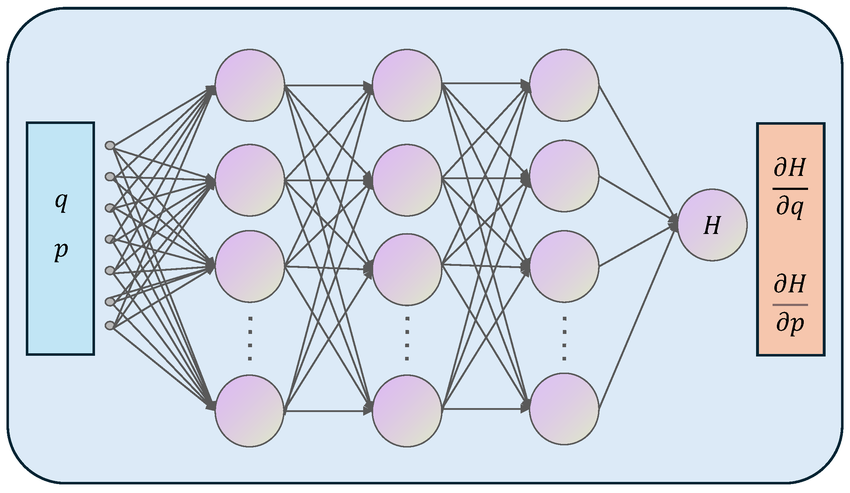

#### 2.3 A loss da HNN

É importante falar sobre a loss usada nessa arquitetura. Ela usa o erro quadrático médio entre as derivadas previstas e as reais. Veja que a loss não é exatamente o output, usamos o que realmente queremos, as derivadas.

$$
L(\theta) = (1/N_{dados}) \sum || (dq/dt_{pred}, dp/dt_{pred}) - (dq/dt_{real}, dp/dt_{real}) ||^2
$$

Um ponto de importância e teste de sanidade da HNN é sobre a garantia de conservação. Isso é, qualquer trajetória que siga exatamente o campo Hamiltoniano definido por $\^H_\theta$ conseva $\^H_\theta$. Isso acontece pois:

$$
\frac{d\^H}{dt} = \frac{\partial\^H}{\partial q} \cdot \frac{dq}{dt} + \frac{\partial\^H}{\partial p} \cdot \frac{dp}{dt} = \frac{\partial\^H}{\partial q} \cdot \frac{\partial\^H}{\partial p} + \frac{\partial^H}{\partial p} \cdot -\frac{\partial\^H}{\partial q} = 0
$$

Ou seja, o erro de conservação de energia deve ser zero para qualquer HNN independentemente dos parâmetros, sendo uma grande vantagem em comparação às redes tradicionais.

#### 2.4 Os hiperparâmetros da HNN

Os hiperparâmetros escolhidos afetam diretamente a qualidade da estrutura hamiltoniana aprendida. Isso é destaque por 3 pontos principais:
1) Propagação de erros: Os erros acumulam ao longo das trajetórias (uma bola de neve)
2) Multi-escala: o sistema tem modos de múltiplas frequências, a rede precisa representar todas simultaneamente.
3) Regularidade: A função $\^H$ precisa ser suabe.

Nesse problema, as funções de ativação serão de grande importância, pois a escolha da errada resultaria em não conseguir representar adequadamente as variações do Hamiltoniano, resultando em trajetórias que violam a física. Usaremos a tanh, SiLU, GELU, Softplus.

A teórica grande importância dos hiperparâmetros para a qualidade do resultado, motivou o teste de diferentes otimizadores, para que assim possa se fazer uma análise de:

1) O quão importantes são os hiperparâmetros para a convergência?
2) Qual a melhor função de ativação?
3) Como cada um dos otimizadores usados se comportam para esse problema?

### 3 O problema

#### 3.1 O landscape

O landscape da loss é a função que mapeia cada combinação de hiperparâmetros para a performance do modelo treinado com esses hiperparâmetros. O espaço de hiperparâmetros (h) tem em deep learning, geralmente 5-10 dimensões (h= (lr, hidden_dim, n_layers, activation, batch_size, weight_decay)). Obtemos o valor de performance L(h) após treinar a rede.


Se o landscape fosse covexo, qualquer método de otimização encontraria o ótimo facilmente. Porém, o landscape de HPO de uma HNN é multimodal e não convexo:
1) Interações entre hiperparâmetros: a melhor taxa de aprendizado depende do batch size. O melhor número de camadas depende da dimensão oculta...
2) Platôs e barreiras: algumas combinações de hiperparâmetros fazem a rede não aprender, criando platôs.
3) O sistema físico projeta sua complexidade na loss: O landscape de loss da HNN reflete a estrutura do sistema físico que a rede está tentando aprender.

#### 3.2 Como o $\sigma_J$ afeta o landscape?

Com $\sigma_J = 0$ (sem desordem): 
Os acoplamentos são todos zero. Os osciladores são independentes e o Hamiltoniano é separável:
H = Σᵢ (½pᵢ² + λ/4 qᵢ⁴)
A HNN precisa aprender uma função que é uma soma de funções idênticas. O landscape de loss é relativamente suave, mesmo subótimo, uma boa inicialização converge razoavelmente bem.

Com σ_J = 0.5 (desordem fraca):
Os acoplamentos existem mas são pequenos. O landscape começa a mostrar estrutura multiescala — existem boas regiões e regiões ruins, mas as transições entre elas são graduais.

Com σ_J = 1.0 (desordem moderada):
A competição entre acoplamentos cria modos com frequências muito heterogêneas. A rede precisa capturar dinâmicas muito diferentes simultaneamente. O landscape torna-se mais rugoso, com múltiplos mínimos locais de qualidade semelhante.

Com σ_J = 2.0 (desordem forte):
O sistema está em regime fortemente frustrado. As frequências dos modos normais variam drasticamente. Alguns pares de osciladores têm acoplamentos muito fortes, criando dinâmica rápida, enquanto outros têm acoplamentos fracos, criando dinâmica lenta. O landscape de loss é analogamente rugoso: existem muitos mínimos locais de qualidade variável, e o ótimo global é difícil de encontrar.



#### 3.3 A hipótese

A hipótese testável: o ranking entre os métodos de HPO (Optuna, CMA-ES, TuRBO) muda com σ_J. Para desordem fraca, o TPE do Optuna (que modela correlações entre hiperparâmetros) pode ser suficiente. Para desordem forte, pode ser necessário um método com trust regions adaptativas (TuRBO) ou com estratégia evolucionária que explore o espaço globalmente (CMA-ES).

| Regime de desordem | Caráter do landscape | Hipótese sobre ranking |
|-------------------|---------------------|----------------------|
| σ_J = 0.0 | Suave, quasi-convexo | TPE ≈ CMA ≈ TuRBO |
| σ_J = 0.5 | Estruturado, poucas correlações | TPE ≥ CMA ≥ TuRBO |
| σ_J = 1.0 | Rugoso, correlações fortes | CMA > TuRBO > TPE |
| σ_J = 2.0 | Altamente multimodal | TuRBO > CMA > TPE |

### 4. TuRBO

#### 4.1 Introdução

O Trust Region Bayesian Optimization (TuRBO) foi proposto em 2019 pela Uber, em que ocorrem otimizações locais simultâneas usando modelos probabilísticos independentes. Cada um dos modelos locais aproveitam a vantagem do BO (robustez para ruído e estimativa da incerteza), enquanto permite modelagem heterogênea.

#### 4.2 O problema

Precisamos encontrar um $x^*$ tal que $x^* \in \Omega$ e $f(x^*) \leq f(x), \space \forall x \in \Omega$

Ou seja, desejamos encontrar um $x^*$, no domínio, que é mínimo da função para todo o conjunto imagem. Usaremos $f: \Omega \to \mathbb{R}$ e $\Omega = [0, 1]^d$. A limitação de a função ter valores somente entre 0 e 1 em cada dimensão pode ser contornada ao aplicar uma transformação linear na função, para a limitar nesse intervalo.

Vejamos primeiro como funciona cada tentativa local, para após entender como operam simultâneamente

#### 4.3 Trust Region

<div align="center">
    <img src="https://pic4.zhimg.com/v2-48361baad5e54c267e5c8cef43883d33_1440w.jpg" width="800">
</div>
https://pic4.zhimg.com/v2-48361baad5e54c267e5c8cef43883d33_1440w.jpg

As Trust Regions (TR) são regiões no espaço que o modelo tenta prever a forma e acredita ter confiança em suas aproximações. O modelo tenta buscar a solução dentro dessa região.

Escolhe-se como Trust Region um hiperretângulo centrado na melhor solução até o momento ($x^*$) ou, para dados com ruído, o ponto de menor média após aplicar o processo gaussiano (GP). Inicialize-se o retângulo com lados lados $L_{init}$ em cada dimensão, que será atualizado para:

$$
L_i = \frac{\lambda_iL}{(\prod_{j=1}^d\lambda_j)^{1/d}}
$$

Em que o lambda é o lengthscale do GP na dimensão. Isso é importante, pois se o $\lambda$ for grande, significa que está variando lentamente na região, podendo avançar mais, ou o contrário se $\lambda$ for pequeno. Além disso, a equação mantém o volume total como $L^{d}_{init}$.

É usado agora uma aquisition function para eleger no espaço da Trust Region q pontos possíveis, objetivando-se resolver o subproblema dentro da região. Para isso, é usado um algoritmo em que define-se sucesso se o ponto conseguiu diminuir a função, enquanto fracasso se não conseguiu. Caso o modelo atinja um número arbitrário definido de sucessos, o lado L deverá dobrar e tentar de novo. Caso atinja o número de fracassos, os lados são divididos por 2. Se o lado encolher para menor que uma marca arbitrária $L_{min}$ anteriormente definida, os lados são reinicializados para $L_{init}$, e o mesmo se os lados passarem de $L_{max}$

Dessa forma, consegue-se manter uma trust region eficaz e explorar os menores valores possíveis com ela.

#### 4.4 O TuRBO

Porém, o que acontece no TuRBO é que são geradas m trust regions simultâneamente, começadas de pontos diferentes. Assim, o TuRBO precisa escolher um conjunto de q pontos para avaliar, mas esses pontos podem vir de qualquer uma das m trust regions ativas. O desafio é decidir, ao mesmo tempo, de qual região explorar e qual ponto específico dentro dela escolher, sem tratar essas duas decisões separadamente.

Para resolver isso, o modelo usa Thompson Sampling (TS) de forma global. Nele, em vez de escolher primeiro uma trust region e depois otimizar dentro dela, o TuRBO faz com que todas as trust regions compitam entre si a cada ponto selecionado.

Para selecionar o i-ésimo ponto do batch, o algoritmo começa amostrando, em cada trust region, uma função possível a partir do modelo GP local dessa região. Essa função amostrada representa uma hipótese plausível de como a função objetivo se comporta naquela região, dado o que já foi observado. Em seguida, dentro de cada trust region, ele resolve um problema de otimização local: encontra o ponto que minimiza essa função amostrada dentro dos limites da trust region.

Nesse momento, cada trust region produziu exatamente um candidato, que é o melhor ponto segundo a função que ela “imaginou”. O próximo passo é comparar esses candidatos entre todas as trust regions. O algoritmo então escolhe aquele cujo valor (na função amostrada correspondente) é o menor entre todos — ou seja, o ponto que parece mais promissor considerando todas as regiões simultaneamente.

Esse processo gera um único ponto do batch. Para construir o batch completo de tamanho q, o procedimento é repetido q vezes, e a cada repetição novas funções são amostradas dos GPs. Isso faz com que a escolha de pontos seja naturalmente estocástica e balanceie exploração e exploração: trust regions mais promissoras tendem a produzir melhores candidatos com mais frequência, mas regiões menos exploradas ainda têm chance de serem escolhidas devido à incerteza capturada pelo GP.

Assim, o TuRBO evita ter que decidir explicitamente qual trust region explorar. Em vez disso, essa decisão emerge automaticamente do processo de amostragem e competição entre regiões, permitindo que o algoritmo distribua seu orçamento de avaliações de forma adaptativa e eficiente.

### 5. CMA-ES

#### 5.1 Introdução

O CMA-ES (Covariance Matrix Adaptation Evolution Strategy) foi proposto em 1990 por Nikolaus Hansen e Andreas Ostermeier. Ele é um algoritmo derivative-free, ou seja, ele não usa a derivada para a minimização de seu valor, sendo útil ao problema de otimização de hiperparâmetros de uma rede neural.

#### 5.2 A matriz de covariância

O CMA tem como parte mais importante a matriz de covariância. Ele usa o histórico de soluções para entender a geometria da função. Por exemplo, se os candidatos se concentrarem em uma direção, a matriz de covariância se alonga nessa mesma direção. 

O algoritmo usa dois mecanismos:

- Rank-one update: atualiza C (a matriz de covariância) com base no caminho evolutivo, que acumula a direção de movimento da média ao longo das gerações.

- Rank-$\mu$ update: Atualiza C combinando as direções do $\mu$ melhores indivíduos da geração atual, acelerando a adaptação em populações maiores.

#### 5.3 O algoritmo

O CMA-ES, para a busca, mantém uma distribuição gaussiana multivariada:
$$
x \space \sim \space \mathcal{N}(m, \sigma^2C)
$$

Onde m é a média, $\sigma$ é o tamanho do passo global e C a matriz de covariância.

A cada iteração, o algoritmo percorre:

1) Amostragem: Gera uma população de $\lambda$ candidatos a partir da distribuição atual.

2) Seleção: Avalia cada candidato e seleciona os $\mu$ melhores.

3) Atualização: Ajusta m, $\sigma$ e C com base nos melhores candidatos. 

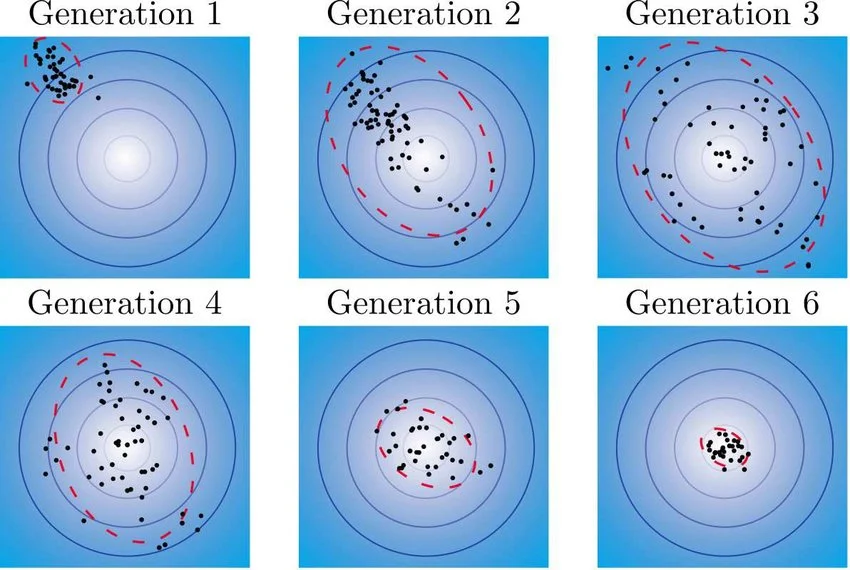

### 6. Código

#### Funções de Simulação do Sistema Físico

Aqui são definidas as funções responsáveis por simular o sistema de osciladores acoplados com desordem. make_J gera a matriz de acoplamento simétrica com entradas gaussianas aleatórias. hamiltonian calcula o valor da energia total do sistema. equations_of_motion implementa as equações Hamiltonisnas, as derivadas temporais de $q$ e $p$. simulate integra numericamente as trajetórias usando o método RK45 a partir de condições iniciais aleatórias.

In [1]:
import numpy as np
from scipy.integrate import solve_ivp

def make_J(N, sigma_J, seed=None):
    rng = np.random.default_rng(seed)
    A = rng.normal(0, sigma_J / np.sqrt(N), (N, N))
    return (A + A.T) / 2  # simetria

def hamiltonian(q, p, J, lam):
    return 0.5 * np.sum(p**2) + 0.5 * q @ J @ q + (lam / 4) * np.sum(q**4)

def equations_of_motion(t, state, J, lam):
    N = len(state) // 2
    q, p = state[:N], state[N:]
    dq = p
    dp = -(J @ q) - lam * q**3
    return np.concatenate([dq, dp])

def simulate(N, sigma_J, lam, n_trajs, t_span, dt, seed=0):
    J = make_J(N, sigma_J, seed)
    rng = np.random.default_rng(seed + 1)
    
    trajs = []
    for _ in range(n_trajs):
        q0 = rng.normal(0, 1, N)
        p0 = rng.normal(0, 1, N)
        state0 = np.concatenate([q0, p0])
        
        sol = solve_ivp(
            equations_of_motion,
            t_span,
            state0,
            args=(J, lam),
            method='RK45',
            max_step=dt,
            dense_output=False,
            rtol=1e-8, atol=1e-10
        )
        trajs.append(sol)
    return J, trajs

#### Parâmetros Globais do Experimento

Define os hiperparâmetros físicos da simulação: N=8 osciladores, não-linearidade fraca lam=0.1, horizonte de tempo $t \in [0, 20]$ com passo dt=0.05 e 200 trajetórias por realização de $J$. Os quatro níveis de desordem SIGMA_LEVELS = [0.0, 0.5, 1.0, 2.0] cobrem o espectro desde osciladores independentes até o regime fortemente frustrado, e serão usados em todos os experimentos comparativos.

In [ ]:
N = 8
lam = 0.1 
t_span = (0, 20)
dt = 0.05   
n_trajs = 200

SIGMA_LEVELS = [0.0, 0.5, 1.0, 2.0]

#### Preparação do Dataset e DataLoaders

Converte as trajetórias simuladas em pares supervisionados $\{(\mathbf{x}_t, \dot{\mathbf{x}}_t)\}$ para treinar a HNN. extract_dataset percorre cada trajetória e calcula as derivadas analíticas $(dq/dt, dp/dt)$ como alvo. HamiltonianDataset encapsula os tensores em um dataset do PyTorch. make_dataloaders divide os dados em treino (70%), validação (15%) e teste (15%) e retorna os três DataLoaders prontos para uso.

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader, random_split

def extract_dataset(trajs, J, lam):
    #Extrai pares (estado, derivada) de todas as trajetórias.
    X, Y = [], []
    for sol in trajs:
        states = sol.y.T  # shape: (T, 2N)
        N = states.shape[1] // 2
        for state in states:
            q, p = state[:N], state[N:]
            dq = p
            dp = -(J @ q) - lam * q**3
            X.append(state)
            Y.append(np.concatenate([dq, dp]))
    
    X = torch.tensor(np.array(X), dtype=torch.float32)
    Y = torch.tensor(np.array(Y), dtype=torch.float32)
    return X, Y

class HamiltonianDataset(Dataset):
    def __init__(self, X, Y):
        self.X = X
        self.Y = Y
    def __len__(self): return len(self.X)
    def __getitem__(self, i): return self.X[i], self.Y[i]

def make_dataloaders(X, Y, batch_size, split=(0.7, 0.15, 0.15)):
    ds = HamiltonianDataset(X, Y)
    n = len(ds)
    n_train = int(n * split[0])
    n_val = int(n * split[1])
    n_test = n - n_train - n_val
    train, val, test = random_split(ds, [n_train, n_val, n_test])
    return (
        DataLoader(train, batch_size=batch_size, shuffle=True),
        DataLoader(val, batch_size=batch_size),
        DataLoader(test, batch_size=batch_size)
    )

#### Arquitetura da Rede Neural Hamiltoniana (HNN)

Define as duas classes centrais do projeto. MLP constrói um perceptron multicamada genérico com profundidade e ativação configuráveis (tanh, SiLU, GELU, Softplus), produzindo um escalar de saída. HNN envolve o MLP para aprender $\hat{H}_\theta(q,p)$ e deriva automaticamente as equações do movimento via torch.autograd.grad: $dq/dt = +\partial\hat{H}/\partial p$ e $dp/dt = -\partial\hat{H}/\partial q$. Essa estrutura garante conservação de energia por construção.

In [ ]:
import torch.nn as nn

class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dim, n_layers, activation):
        super().__init__()
        act_map = {
            'tanh': nn.Tanh,
            'silu': nn.SiLU,
            'gelu': nn.GELU,
            'softplus': nn.Softplus
        }
        layers = [nn.Linear(input_dim, hidden_dim), act_map[activation]()]
        for _ in range(n_layers - 1):
            layers += [nn.Linear(hidden_dim, hidden_dim), act_map[activation]()]
        layers += [nn.Linear(hidden_dim, 1)]
        self.net = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.net(x)


class HNN(nn.Module):
    def __init__(self, N, hidden_dim, n_layers, activation):
        super().__init__()
        self.N = N
        self.H_net = MLP(2 * N, hidden_dim, n_layers, activation)

    def forward(self, x):
        x = x.detach().requires_grad_(True)
        
        H = self.H_net(x).sum()
        grad = torch.autograd.grad(H, x, create_graph=True)[0]
        
        dq_pred =  grad[:, self.N:]   #  ∂H/∂p
        dp_pred = -grad[:, :self.N]   # -∂H/∂q
        return torch.cat([dq_pred, dp_pred], dim=1)

#### Loop de Treinamento da HNN

Implementa o ciclo completo de treino com otimizador Adam e scheduler cosseno (CosineAnnealingLR). A cada época, o modelo é treinado minimizando o MSE entre as derivadas previstas e as reais, com clipping de gradiente (norm ≤ 1.0) para estabilidade. Na validação, torch.enable_grad() é reativado explicitamente dentro de torch.no_grad() para que o autograd.grad interno da HNN funcione corretamente. A função retorna a melhor perda de validação atingida ao longo do treinamento.

In [ ]:
def train_hnn(model, train_loader, val_loader,
              lr, weight_decay, n_epochs, device='cpu'):
    model = model.to(device)
    optimizer = torch.optim.Adam(
        model.parameters(), lr=lr, weight_decay=weight_decay
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=n_epochs
    )

    best_val_loss = float('inf')
    for epoch in range(n_epochs):
        model.train()
        for X_batch, Y_batch in train_loader:
            X_batch = X_batch.to(device)
            Y_batch = Y_batch.to(device)

            Y_pred = model(X_batch)
            loss = nn.MSELoss()(Y_pred, Y_batch)

            optimizer.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

        scheduler.step()

        model.eval()
        val_losses = []
        with torch.no_grad():
            for X_batch, Y_batch in val_loader:
                X_batch = X_batch.to(device)
                Y_batch = Y_batch.to(device)
                with torch.enable_grad():    
                    Y_pred = model(X_batch)
                val_losses.append(nn.MSELoss()(Y_pred, Y_batch).item())

        val_loss = np.mean(val_losses)
        if val_loss < best_val_loss:
            best_val_loss = val_loss

    return best_val_loss

#### Espaço de Busca de Hiperparâmetros

Define o domínio de otimização de hiperparâmetros que todos os métodos de HPO irão explorar. São 6 variáveis: taxa de aprendizado lr e weight_decay em escala logarítmica, hidden_dim e n_layers inteiros, e activation e batch_size categóricos. Esse espaço misto e de baixa dimensão é suficiente para diferenciar os métodos Optuna (TPE), CMA-ES e TuRBO sem tornar o custo computacional proibitivo.

In [ ]:
SEARCH_SPACE = {
    'lr':           ('log_float', 1e-4, 1e-2),
    'hidden_dim':   ('int',       32, 256),
    'n_layers':     ('int',       1, 4),
    'activation':   ('cat',       ['tanh', 'silu', 'gelu', 'softplus']),
    'batch_size':   ('cat',       [64, 128, 256, 512]),
    'weight_decay': ('log_float', 1e-6, 1e-2),
}

#### Função Objetivo do HPO

Esta é a função que todos os otimizadores de hiperparâmetros irão minimizar. Para um dado conjunto de parâmetros params e nível de desordem sigma_J, ela: simula as trajetórias, prepara os DataLoaders, instancia uma HNN e a treina por 50 épocas, retornando a melhor perda de validação. O número reduzido de épocas é intencional, o objetivo é avaliar a qualidade dos hiperparâmetros, não o treino prolongado.

In [ ]:
def objective(params, sigma_J, N=8, lam=0.1, n_epochs=50, seed=42):
    
    J, trajs = simulate(N, sigma_J, lam, n_trajs=200, 
                        t_span=(0,20), dt=0.05, seed=seed)
    X, Y = extract_dataset(trajs, J, lam)
    train_loader, val_loader, _ = make_dataloaders(
        X, Y, batch_size=params['batch_size']
    )
    
    model = HNN(
        N=N,
        hidden_dim=params['hidden_dim'],
        n_layers=params['n_layers'],
        activation=params['activation']
    )
    
    val_loss = train_hnn(
        model, train_loader, val_loader,
        lr=params['lr'],
        weight_decay=params['weight_decay'],
        n_epochs=n_epochs
    )
    return val_loss

#### Otimização de Hiperparâmetros com Optuna (TPE)

Implementa o otimizador baseado em Optuna com o amostrador TPE (*Tree-structured Parzen Estimator*). O TPE constrói modelos probabilísticos separados para regiões boas e ruins do espaço de hiperparâmetros e os usa para sugerir novos candidatos. A função retorna o melhor valor encontrado, os melhores parâmetros e o histórico completo de losses por trial, permitindo análise de convergência posterior.

In [8]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

def run_optuna(sigma_J, n_trials=50, seed=42):
    def optuna_objective(trial):
        params = {
            'lr':           trial.suggest_float('lr', 1e-4, 1e-2, log=True),
            'hidden_dim':   trial.suggest_int('hidden_dim', 32, 256),
            'n_layers':     trial.suggest_int('n_layers', 1, 4),
            'activation':   trial.suggest_categorical('activation', 
                                ['tanh','silu','gelu','softplus']),
            'batch_size':   trial.suggest_categorical('batch_size', 
                                [64, 128, 256, 512]),
            'weight_decay': trial.suggest_float('weight_decay', 1e-6, 1e-2, log=True),
        }
        return objective(params, sigma_J)
    
    sampler = optuna.samplers.TPESampler(seed=seed)
    study = optuna.create_study(direction='minimize', sampler=sampler)
    study.optimize(optuna_objective, n_trials=n_trials)
    
    return {
        'best_value': study.best_value,
        'best_params': study.best_params,
        'history': [t.value for t in study.trials]
    }

#### Otimização de Hiperparâmetros com CMA-ES

Implementa o *Covariance Matrix Adaptation Evolution Strategy*. Como o espaço de busca misto (contínuo + categórico) não é nativo ao CMA-ES, as variáveis são codificadas num vetor contínuo de dimensão 6 e decodificadas via decode(). O algoritmo evolui uma distribuição gaussiana multivariada, adaptando a matriz de covariância para explorar as direções mais promissoras. verbose=-9 silencia a saída padrão do CMA.

In [9]:
import cma

def run_cmaes(sigma_J, n_trials=50, seed=42):
    # Encoding: [log_lr, hidden_dim_norm, n_layers_norm, act_idx, bs_idx, log_wd]
    # Variáveis categóricas são tratadas como inteiros após round()
    
    activations = ['tanh', 'silu', 'gelu', 'softplus']
    batch_sizes  = [64, 128, 256, 512]
    
    def decode(x):
        lr          = np.clip(np.exp(x[0]), 1e-4, 1e-2)
        hidden_dim  = int(np.clip(round(x[1] * 224 + 32), 32, 256))
        n_layers    = int(np.clip(round(x[2] * 3 + 1), 1, 4))
        act_idx     = int(np.clip(round(x[3] * 3), 0, 3))
        bs_idx      = int(np.clip(round(x[4] * 3), 0, 3))
        wd          = np.clip(np.exp(x[5]), 1e-6, 1e-2)
        return {
            'lr': lr, 'hidden_dim': hidden_dim, 'n_layers': n_layers,
            'activation': activations[act_idx],
            'batch_size': batch_sizes[bs_idx],
            'weight_decay': wd
        }
    
    history = []
    x0 = [np.log(1e-3), 0.5, 0.5, 1.5, 1.5, np.log(1e-4)]
    sigma0 = 0.3
    
    es = cma.CMAEvolutionStrategy(x0, sigma0, {
        'seed': seed,
        'maxfevals': n_trials,
        'verbose': -9
    })
    
    while not es.stop() and len(history) < n_trials:
        solutions = es.ask()
        fitnesses = [objective(decode(x), sigma_J) for x in solutions]
        es.tell(solutions, fitnesses)
        history.extend(fitnesses)
    
    best_idx = np.argmin(history)
    return {
        'best_value': min(history),
        'history': history
    }

#### Otimização de Hiperparâmetros com TuRBO

Implementa o Trust Region Bayesian Optimization usando BoTorch. A classe TuRBOState mantém o estado da trust region, seu tamanho length, contadores de sucesso/fracasso e a lógica de expansão/contração/reinício. run_turbo inicializa com n_init=10 pontos via Latin Hypercube, ajusta um GP local a cada iteração, otimiza a aquisição EI dentro da trust region e atualiza o estado. Quando a trust region encolhe abaixo de length_min, ela é reiniciada.

In [10]:
from botorch.utils.transforms import unnormalize, normalize
from botorch.models import SingleTaskGP
from botorch.fit import fit_gpytorch_mll
from botorch.acquisition import qExpectedImprovement
from botorch.optim import optimize_acqf
from gpytorch.mlls import ExactMarginalLogLikelihood
import torch

class TuRBOState:
    def __init__(self, dim, batch_size=1):
        self.dim = dim
        self.length = 0.8
        self.length_min = 0.5**7
        self.length_max = 1.6
        self.failure_counter = 0
        self.failure_tolerance = max(4, dim)
        self.success_counter = 0
        self.success_tolerance = 10
        self.best_value = float('inf')
        self.restart_triggered = False
    
    def update(self, new_value):
        if new_value < self.best_value - 1e-3 * abs(self.best_value):
            self.success_counter += 1
            self.failure_counter = 0
        else:
            self.failure_counter += 1
            self.success_counter = 0
        
        if self.success_counter >= self.success_tolerance:
            self.length = min(self.length * 2, self.length_max)
            self.success_counter = 0
        if self.failure_counter >= self.failure_tolerance:
            self.length /= 2
            self.failure_counter = 0
        
        self.best_value = min(self.best_value, new_value)
        if self.length < self.length_min:
            self.restart_triggered = True
def run_turbo(sigma_J, n_trials=50, n_init=10, seed=42):
    assert n_init > 0, f"n_init deve ser > 0, recebido: {n_init}"
    assert n_init < n_trials, f"n_init ({n_init}) deve ser menor que n_trials ({n_trials})"
    
    torch.manual_seed(seed)
    dim = 6
    bounds = torch.tensor([
        [np.log(1e-4), 0, 1, 0, 0, np.log(1e-6)],   # lower
        [np.log(1e-2), 256, 4, 3, 3, np.log(1e-2)]   # upper
    ], dtype=torch.float64)
    
    activations  = ['tanh', 'silu', 'gelu', 'softplus']
    batch_sizes  = [64, 128, 256, 512]
    
    def decode_turbo(x):
        x = x.numpy()
        return {
            'lr':           float(np.exp(np.clip(x[0], np.log(1e-4), np.log(1e-2)))),
            'hidden_dim':   int(np.clip(round(x[1]), 32, 256)),
            'n_layers':     int(np.clip(round(x[2]), 1, 4)),
            'activation':   activations[int(np.clip(round(x[3]), 0, 3))],
            'batch_size':   batch_sizes[int(np.clip(round(x[4]), 0, 3))],
            'weight_decay': float(np.exp(np.clip(x[5], np.log(1e-6), np.log(1e-2)))),
        }
    
    # Amostragem inicial (Latin Hypercube)
    X_init = torch.zeros(n_init, dim, dtype=torch.float64)
    for j in range(dim):
        X_init[:, j] = torch.linspace(
            bounds[0, j], bounds[1, j], n_init
        )[torch.randperm(n_init)]
    
    Y_init = torch.tensor(
        [objective(decode_turbo(x), sigma_J) for x in X_init],
        dtype=torch.float64
    ).unsqueeze(-1)
    
    X_all, Y_all = X_init.clone(), Y_init.clone()
    state = TuRBOState(dim)
    state.best_value = Y_all.min().item()
    history = Y_all.squeeze().tolist()
    
    # Loop principal TuRBO
    while len(history) < n_trials:
        # Trust region centrada no melhor ponto
        best_idx = Y_all.argmin()
        x_center = X_all[best_idx]
        
        weights = (X_all - x_center).abs().mean(0)
        weights = weights / weights.mean()
        
        tr_lb = torch.clamp(x_center - weights * state.length / 2, bounds[0], bounds[1])
        tr_ub = torch.clamp(x_center + weights * state.length / 2, bounds[0], bounds[1])
        
        # Fit GP dentro da trust region
        X_norm = normalize(X_all, bounds)
        gp = SingleTaskGP(X_norm, (Y_all - Y_all.mean()) / Y_all.std())
        mll = ExactMarginalLogLikelihood(gp.likelihood, gp)
        fit_gpytorch_mll(mll)
        
        # Otimiza aquisição EI dentro da TR
        ei = qExpectedImprovement(gp, best_f=Y_all.min())
        candidate, _ = optimize_acqf(
            ei,
            bounds=torch.stack([
                normalize(tr_lb.unsqueeze(0), bounds).squeeze(),
                normalize(tr_ub.unsqueeze(0), bounds).squeeze()
            ]),
            q=1, num_restarts=5, raw_samples=64
        )
        
        x_new = unnormalize(candidate.detach(), bounds).squeeze()
        y_new = objective(decode_turbo(x_new), sigma_J)
        
        state.update(y_new)
        X_all = torch.cat([X_all, x_new.unsqueeze(0)])
        Y_all = torch.cat([Y_all, torch.tensor([[y_new]], dtype=torch.float64)])
        history.append(y_new)
        
        if state.restart_triggered:
            state = TuRBOState(dim)
            state.best_value = Y_all.min().item()
    
    return {'best_value': min(history), 'history': history}

#### Loop Principal do Experimento

Executa os três métodos de HPO (Optuna, CMA-ES, TuRBO) para cada um dos quatro níveis de desordem sigma_J ∈ {0.0, 0.5, 1.0, 2.0}, repetindo cada combinação por N_SEEDS=5 sementes para significância estatística. Os resultados são armazenados num dicionário aninhado results[sigma_J][seed][método] e salvos em results.json ao final, garantindo reprodutibilidade e persistência dos dados.

In [ ]:
import json
from itertools import product

SIGMA_LEVELS = [0.0, 0.5, 1.0, 2.0]
N_TRIALS     = 50
N_SEEDS      = 5 

results = {}

for sigma_J in SIGMA_LEVELS:
    results[sigma_J] = {}
    print(f"\n=== sigma_J = {sigma_J} ===")
    
    for seed in range(N_SEEDS):
        results[sigma_J][seed] = {}

        print(f"  Optuna seed={seed}...", end=' ', flush=True)
        results[sigma_J][seed]['optuna'] = run_optuna(sigma_J, n_trials=N_TRIALS, seed=seed)
        print("✓")

        print(f"  CMA-ES seed={seed}...", end=' ', flush=True)
        results[sigma_J][seed]['cmaes']  = run_cmaes(sigma_J, n_trials=N_TRIALS, seed=seed)
        print("✓")

        print(f"  TuRBO  seed={seed}...", end=' ', flush=True)
        results[sigma_J][seed]['turbo']  = run_turbo(sigma_J, n_trials=N_TRIALS, seed=seed)
        print("✓")

        

with open('results.json', 'w') as f:
    json.dump(results, f)


=== sigma_J = 0.0 ===
  Optuna seed=0... 

✓
  CMA-ES seed=0... 

✓
  TuRBO  seed=0... 

/home/matheus25022/miniconda3/envs/ilumpy/lib/python3.13/site-packages/botorch/acquisition/monte_carlo.py:415: NumericsWarning: qExpectedImprovement has known numerical issues that lead to suboptimal optimization performance. It is strongly recommended to simply replace

	 qExpectedImprovement 	 --> 	 qLogExpectedImprovement 

instead, which fixes the issues and has the same API. See https://arxiv.org/abs/2310.20708 for details.
  legacy_ei_numerics_warning(legacy_name=type(self).__name__)


/home/matheus25022/miniconda3/envs/ilumpy/lib/python3.13/site-packages/botorch/optim/optimize.py:362: BadInitialCandidatesWarning: Unable to find non-zero acquisition function values - initial conditions are being selected randomly.
  generated_initial_conditions = opt_inputs.get_ic_generator()(


...

/home/matheus25022/miniconda3/envs/ilumpy/lib/python3.13/site-packages/botorch/acquisition/monte_carlo.py:415: NumericsWarning: qExpectedImprovement has known numerical issues that lead to suboptimal optimization performance. It is strongly recommended to simply replace

	 qExpectedImprovement 	 --> 	 qLogExpectedImprovement 

instead, which fixes the issues and has the same API. See https://arxiv.org/abs/2310.20708 for details.
  legacy_ei_numerics_warning(legacy_name=type(self).__name__)
/home/matheus25022/miniconda3/envs/ilumpy/lib/python3.13/site-packages/botorch/optim/optimize.py:362: BadInitialCandidatesWarning: Unable to find non-zero acquisition function values - initial conditions are being selected randomly.
  generated_initial_conditions = opt_inputs.get_ic_generator()(


/home/matheus25022/miniconda3/envs/ilumpy/lib/python3.13/site-packages/botorch/acquisition/monte_carlo.py:415: NumericsWarning: qExpectedImprovement has known numerical issues that lead to suboptimal optimization performance. It is strongly recommended to simply replace

	 qExpectedImprovement 	 --> 	 qLogExpectedImprovement 

instead, which fixes the issues and has the same API. See https://arxiv.org/abs/2310.20708 for details.
  legacy_ei_numerics_warning(legacy_name=type(self).__name__)


/home/matheus25022/miniconda3/envs/ilumpy/lib/python3.13/site-packages/botorch/optim/optimize.py:362: BadInitialCandidatesWarning: Unable to find non-zero acquisition function values - initial conditions are being selected randomly.
  generated_initial_conditions = opt_inputs.get_ic_generator()(


/home/matheus25022/miniconda3/envs/ilumpy/lib/python3.13/site-packages/botorch/acquisition/monte_carlo.py:415: NumericsWarning: qExpectedImprovement has known numerical issues that lead to suboptimal optimization performance. It is strongly recommended to simply replace

	 qExpectedImprovement 	 --> 	 qLogExpectedImprovement 

instead, which fixes the issues and has the same API. See https://arxiv.org/abs/2310.20708 for details.
  legacy_ei_numerics_warning(legacy_name=type(self).__name__)
/home/matheus25022/miniconda3/envs/ilumpy/lib/python3.13/site-packages/botorch/optim/optimize.py:362: BadInitialCandidatesWarning: Unable to find non-zero acquisition function values - initial conditions are being selected randomly.
  generated_initial_conditions = opt_inputs.get_ic_generator()(


✓


#### Cálculo de Métricas de Convergência

Computa três métricas a partir do histórico de losses de cada método: best, o menor valor de validação atingido; auc, a média do mínimo acumulado ao longo dos trials (área sob a curva de convergência, onde menor é melhor); e t10, o índice do primeiro trial em que o método ficou a 10% do mínimo global, medindo a velocidade de convergência.

In [ ]:
def compute_metrics(history):
    history = np.array(history)
    best = history.min()
    
    # AUC normalizada
    cummin = np.minimum.accumulate(history)
    auc = cummin.mean()
    
    # Velocidade de convergência: primeiro trial dentro de 10% do best
    threshold = best * 1.1
    t10 = next((i for i, v in enumerate(cummin) if v <= threshold), len(history))
    
    return {'best': best, 'auc': auc, 't10': t10}

#### Visualização das Curvas de Convergência

Gera uma figura com 4 subgráficos, um por nível de desordem $\sigma_J$, comparando a curva de convergência (mínimo acumulado) dos três métodos. Para cada método, plota a média e o intervalo de ±1 desvio padrão sobre as 5 sementes. O eixo y está em escala logarítmica para destacar diferenças de convergência. A figura é salva em fig1_convergence.pdf com resolução 300 dpi.

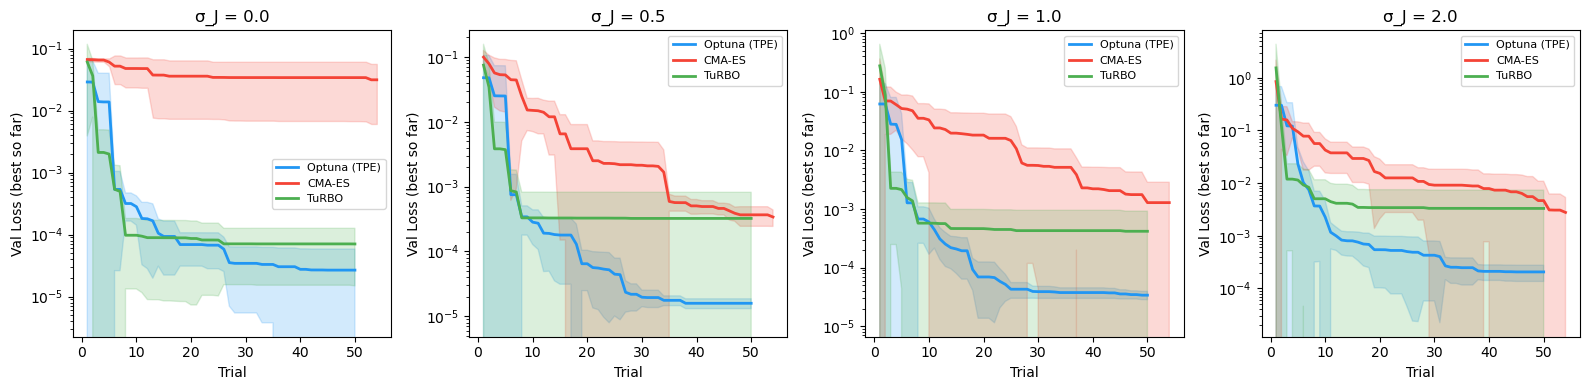

In [13]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=False)
colors = {'optuna': '#2196F3', 'cmaes': '#F44336', 'turbo': '#4CAF50'}
methods = ['optuna', 'cmaes', 'turbo']
labels  = ['Optuna (TPE)', 'CMA-ES', 'TuRBO']

for ax, sigma_J in zip(axes, SIGMA_LEVELS):
    for method, label, color in zip(methods, labels, colors.values()):
        all_histories = [
            np.minimum.accumulate(results[sigma_J][s][method]['history'])
            for s in range(N_SEEDS)
        ]
        mean = np.mean(all_histories, axis=0)
        std  = np.std(all_histories, axis=0)
        
        trials = np.arange(1, len(mean)+1)
        ax.plot(trials, mean, label=label, color=color, lw=2)
        ax.fill_between(trials, mean-std, mean+std, alpha=0.2, color=color)
    
    ax.set_title(f'σ_J = {sigma_J}')
    ax.set_xlabel('Trial')
    ax.set_ylabel('Val Loss (best so far)')
    ax.legend(fontsize=8)
    ax.set_yscale('log')

plt.tight_layout()
plt.savefig('fig1_convergence.pdf', dpi=300)